Realizado por:
* Diogo Vasco 2023226969 
* Rodrigo Gonçalves 2023226160

3.1. Scenario A (Binary Problem) – The objective of this scenario is to classify each instance as,
for example, ‘no stress’ (0) or ‘stress’ (1);

3.2. Scenario B (Multi-Class Problem 1) – The objective of this scenario is to classify the level
of stress as one of five possible levels, e.g. , ‘no stress’ (0), ‘low’ (1), ‘moderate’ (2), ‘high’
(3) and ‘extreme’ (4);

3.3. Scenario C (Multi-Class Problem 2) – The objective of this scenario is to classify the level of
stress as one of 10 possible, e.g., from ‘no stress’ (0) to ‘maximum’ (9).

SVM -> Rodrigo
NN  -> Vasco

In [1]:
import imblearn
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier  
from sklearn.model_selection import cross_val_score  
from sklearn.metrics import precision_score, recall_score, f1_score 
from sklearn.preprocessing import MinMaxScaler 


sns.set_theme()

In [2]:
stressL='sleepStress.csv'
df= pd.read_csv(stressL)

## Exploratory Data Analysis

Before cleaning, we inspect the raw dataset to understand its size, structure, missing values, and the main variable distributions.

In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nNumerical summary:")
display(df.describe().T)
print("\nCategorical summary:")
display(df.describe(include='object').T)
display(df.head())

Shape: (15000, 13)

Data types:
user_id                               int64
age                                   int64
gender                                  str
occupation                              str
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object

Missing values:
user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups   

,count,mean,std,min,25%,50%,75%,max
user_id,15000.0,7500.500000,4330.271354,1.0,3750.75,7500.50,11250.25,15000.0
age,15000.0,38.488467,12.007970,18.0,28.00,38.00,49.00,59.0
daily_screen_time_hours,15000.0,5.501528,2.600085,1.0,3.26,5.49,7.76,10.0
phone_usage_before_sleep_minutes,15000.0,59.708933,34.641858,0.0,29.00,60.00,90.00,119.0
sleep_duration_hours,15000.0,6.509683,1.452689,4.0,5.26,6.49,7.79,9.0
sleep_quality_score,15000.0,6.246362,1.713644,1.0,5.00,6.25,7.50,10.0
stress_level,15000.0,6.980247,2.749382,1.0,4.75,7.38,10.00,10.0
caffeine_intake_cups,15000.0,1.998800,1.414590,0.0,1.00,2.00,3.00,4.0
physical_activity_minutes,15000.0,59.157133,34.525705,0.0,29.00,59.00,89.00,119.0
notifications_received_per_day,15000.0,160.890467,80.856902,20.0,92.00,162.00,231.00,299.0



Categorical summary:


/tmp/ipykernel_6026/2379990646.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object').T)


,count,unique,top,freq
gender,15000,3,Male,7234
occupation,15000,8,Manager,1962


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


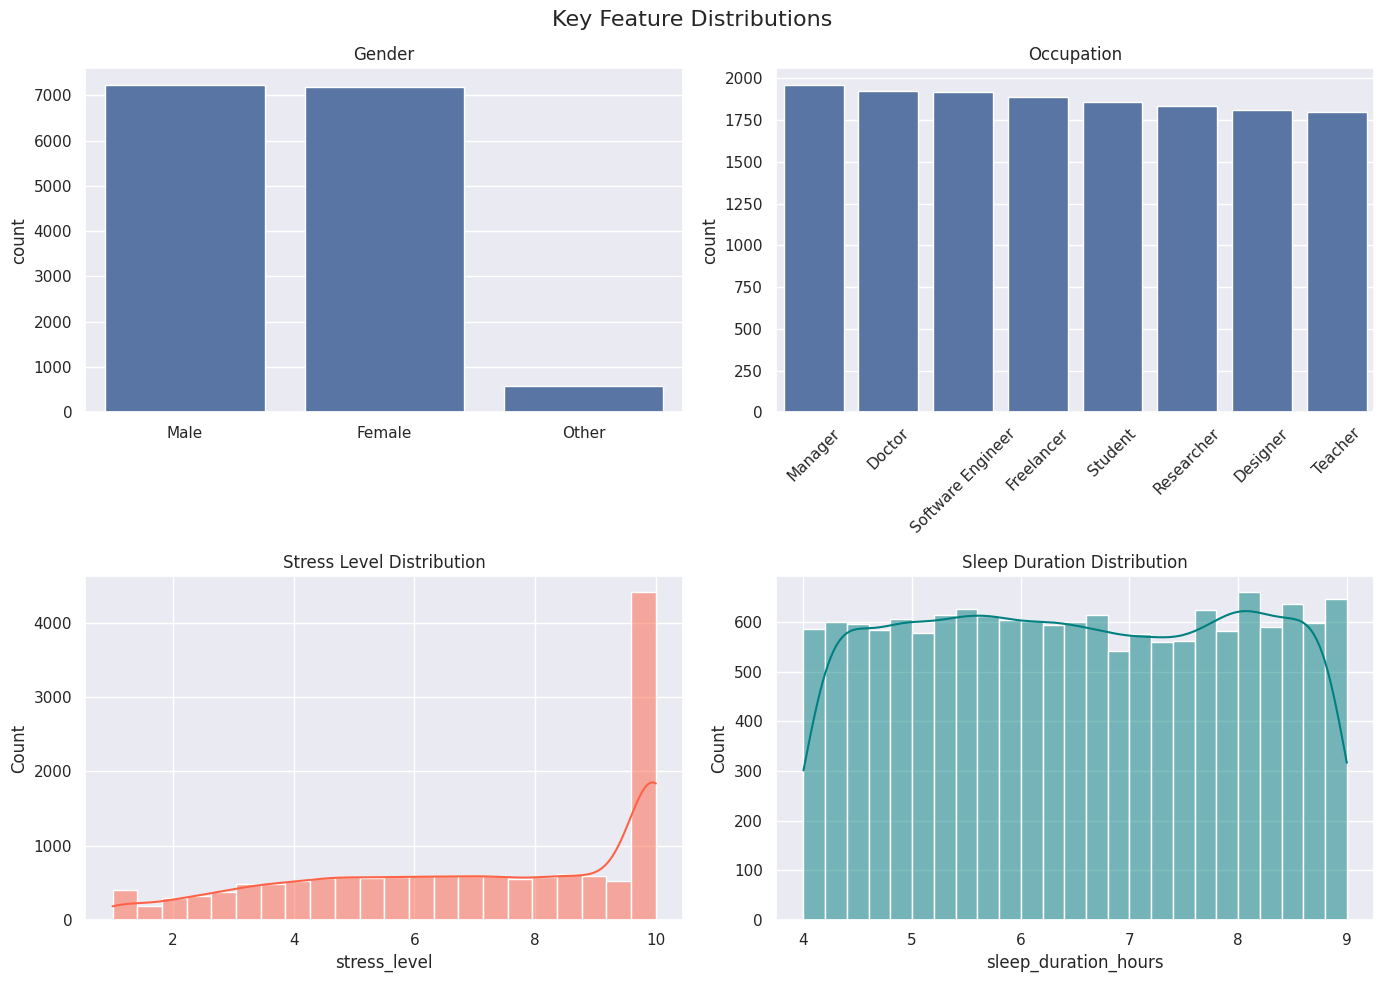

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Feature Distributions', fontsize=16)

sns.countplot(data=df, x='gender', order=df['gender'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('Gender')
axes[0, 0].set_xlabel('')

sns.countplot(data=df, x='occupation', order=df['occupation'].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title('Occupation')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_xlabel('')

sns.histplot(df['stress_level'], kde=True, ax=axes[1, 0], color='tomato')
axes[1, 0].set_title('Stress Level Distribution')

sns.histplot(df['sleep_duration_hours'], kde=True, ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Sleep Duration Distribution')

plt.tight_layout()
plt.show()

sem valores em falta, sem valores duplicados

In [5]:
print(df.isnull().sum())
df.duplicated().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64


np.int64(0)

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() 
corr = pd.DataFrame()
for col in df.columns: 
        corr[col] = le.fit_transform(df[col])

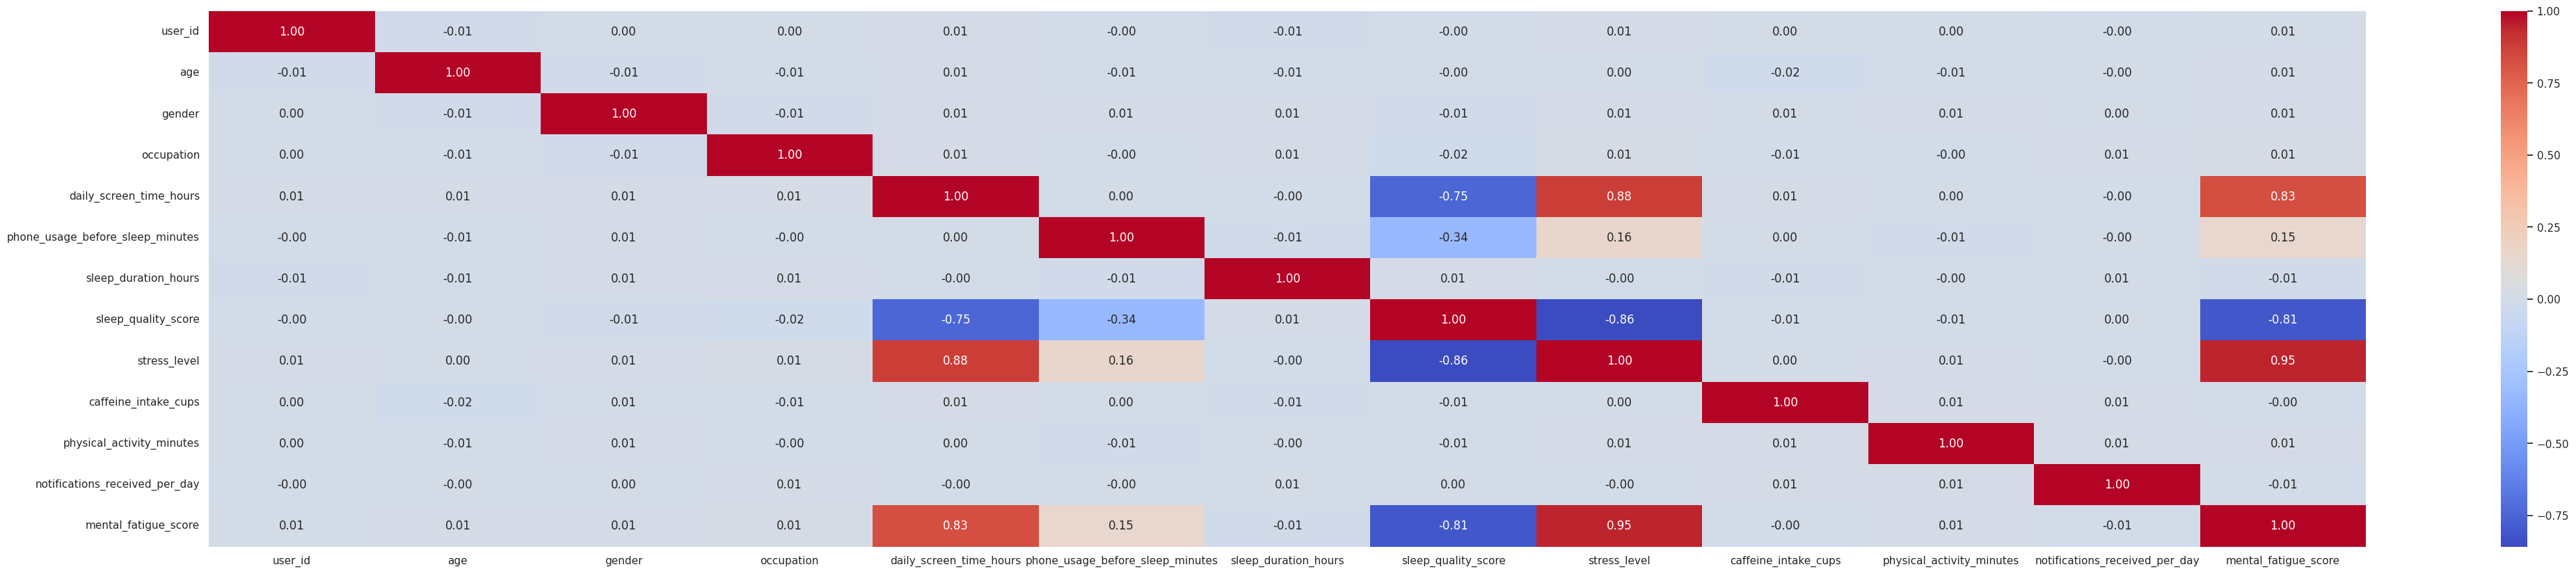

In [7]:
plt.figure(figsize=(50, 10))
correlation_matrix = corr.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

# SVM – Support Vector Machine

Support Vector Machine (SVM) is a supervised learning algorithm that finds the optimal hyperplane that maximises the margin between classes. The kernel trick (RBF, polynomial, etc.) allows SVMs to handle non-linear boundaries effectively.

Three scenarios are evaluated:
- **Scenario A** – Binary classification: *no stress* (0) vs *stress* (1)
- **Scenario B** – 5-class classification: *no stress* (0), *low* (1), *moderate* (2), *high* (3), *extreme* (4)
- **Scenario C** – 10-class classification: levels 0 through 9


## Data Preparation

Encode categorical features, scale numerical features (SVM is sensitive to scale), and build the three target variables.

In [26]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Auto-detect the stress target column ────────────────────────────────
stress_candidates = [c for c in df.columns if 'stress' in c.lower()]
print('Stress-related columns found:', stress_candidates)
print('All columns:', list(df.columns))

# Pick the column with the most unique values (the finest-grained target)
target_col = max(stress_candidates, key=lambda c: df[c].nunique())
print(f'\nUsing target column: "{target_col}"')
print('Unique values:', sorted(df[target_col].unique()))

# ── Encode categorical columns ──────────────────────────────────────────
le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = le.fit_transform(df_enc[col])

# ── Feature matrix (drop ALL stress columns to avoid leakage) ───────────
X_raw = df_enc.drop(columns=stress_candidates)

# ── Scale features (SVM is sensitive to scale) ──────────────────────────
scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)

# ── Build the three target vectors ──────────────────────────────────────
y_raw = df_enc[target_col]
n_unique = y_raw.nunique()
vals_sorted = sorted(y_raw.unique())

# Scenario C: keep as-is (up to 10 classes)
# Re-map to contiguous 0-based integers just in case
y_C = pd.qcut(y_raw, q=min(11, n_unique), labels=False, duplicates='drop')

# Scenario A: binary — bottom half vs top half of the range
midpoint = (vals_sorted[0] + vals_sorted[-1]) / 2
y_A = (y_raw > midpoint).astype(int)

# Scenario B: 5 classes — quantile-based binning for balance
y_B = pd.qcut(y_raw, q=5, labels=False, duplicates='drop')

print('\nClass distribution after mapping:')
print('  A (binary):', dict(y_A.value_counts().sort_index()))
print('  B (5-class):', dict(y_B.value_counts().sort_index()))
print('  C (up to 10-class):', dict(y_C.value_counts().sort_index()))
print(f'\nNumber of classes  ->  A: {y_A.nunique()}  B: {y_B.nunique()}  C: {y_C.nunique()}')


Stress-related columns found: ['stress_level']
All columns: ['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'stress_level', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']

Using target column: "stress_level"
Unique values: [np.float64(1.0), np.float64(1.01), np.float64(1.02), np.float64(1.03), np.float64(1.04), np.float64(1.05), np.float64(1.06), np.float64(1.07), np.float64(1.08), np.float64(1.09), np.float64(1.1), np.float64(1.11), np.float64(1.12), np.float64(1.13), np.float64(1.14), np.float64(1.15), np.float64(1.16), np.float64(1.17), np.float64(1.18), np.float64(1.19), np.float64(1.2), np.float64(1.21), np.float64(1.22), np.float64(1.23), np.float64(1.24), np.float64(1.25), np.float64(1.26), np.float64(1.27), np.float64(1.28), np.float64(1.29), np.float64(1.3), np.float64(1.31), np.float64(1.32), np.float64(1.33),

## Helper – Train & Evaluate SVM

A reusable function that:
1. Applies **RandomOverSampler** to handle class imbalance
2. Trains an SVM with the chosen kernel
3. Evaluates with **Stratified K-Fold cross-validation** and a hold-out test set
4. Plots the confusion matrix

In [27]:
def train_evaluate_svm(X, y, scenario_name, kernel='rbf', C=1.0,
                        n_splits=5, test_size=0.2, random_state=42):
    """
    Train an SVM classifier and report cross-val + test-set metrics.
    Applies RandomOverSampler only when there are >= 2 classes in the split.
    """
    from collections import Counter
    from imblearn.over_sampling import SMOTE


    # Drop NaN rows that qcut may introduce
    mask = y.notna()
    X_ = X[mask].reset_index(drop=True)   
    y_ = y[mask].reset_index(drop=True)   

    class_counts = Counter(y_)
    valid_classes = {cls for cls, cnt in class_counts.items() if cnt >= 2}
    valid_mask = y_.isin(valid_classes)
    X_ = X_[valid_mask].reset_index(drop=True)
    y_ = y_[valid_mask].reset_index(drop=True)

    n_classes = y_.nunique()
    if n_classes < 2:
        print(f'[SKIP] {scenario_name}: only {n_classes} class(es) found — cannot train.')
        return None

    print(f'\n{"="*65}')
    print(f'  {scenario_name}')
    print(f'  kernel={kernel}  C={C}  classes={sorted(y_.unique())}')
    print(f'{"="*65}')

    #Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_, y_, test_size=test_size, stratify=y_, random_state=random_state)

    #  Oversampling (training set only) 
    # Only oversample if every class has >= 1 sample in training
    min_samples = min(Counter(y_train).values())
    if min_samples >= 1 and y_train.nunique() >= 2:
        smote = SMOTE(random_state=random_state, k_neighbors=3)  
        X_res, y_res = smote.fit_resample(X_train, y_train)
        print('  [INFO] SMOTE utilizado.')
    else:
        X_res, y_res = X_train, y_train
        print('  [INFO] Oversampling skipped (not enough samples per class).')

    # Reduce folds if dataset too small
    actual_splits = min(n_splits, int(min(Counter(y_res).values())))
    actual_splits = max(actual_splits, 2)
    skf = StratifiedKFold(n_splits=actual_splits, shuffle=True,
                          random_state=random_state)
    svm_cv = SVC(kernel=kernel, C=C, random_state=random_state)
    cv_scores = cross_val_score(svm_cv, X_res, y_res,
                                cv=skf, scoring='accuracy')
    print(f'Cross-val accuracy ({actual_splits}-fold): '
          f'{cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    svm_final = SVC(kernel=kernel, C=C, random_state=random_state)
    svm_final.fit(X_res, y_res)

    y_pred = svm_final.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f'\nTest-set results:')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}  (weighted)')
    print(f'  Recall   : {rec:.4f}  (weighted)')
    print(f'  F1-Score : {f1:.4f}  (weighted)')
    print(f'\nClassification Report:\n')
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix 
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, colorbar=False,
        cmap='Blues', normalize='true')
    ax.set_title(f'Confusion Matrix - {scenario_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

    return {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
            'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1}


## 3.1 Scenario A – Binary Classification

The model must distinguish between **no stress** (class 0) and **stress** (class 1). Binary SVMs are particularly well-studied and often achieve high margins with an RBF kernel.


  Scenario A - Binary (no stress vs stress)
  kernel=rbf  C=2  classes=[np.int64(0), np.int64(1)]
  [INFO] SMOTE utilizado.
Cross-val accuracy (5-fold): 0.9560 ± 0.0027

Test-set results:
  Accuracy : 0.9430
  Precision: 0.9437  (weighted)
  Recall   : 0.9430  (weighted)
  F1-Score : 0.9432  (weighted)

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       960
           1       0.97      0.95      0.96      2040

    accuracy                           0.94      3000
   macro avg       0.93      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



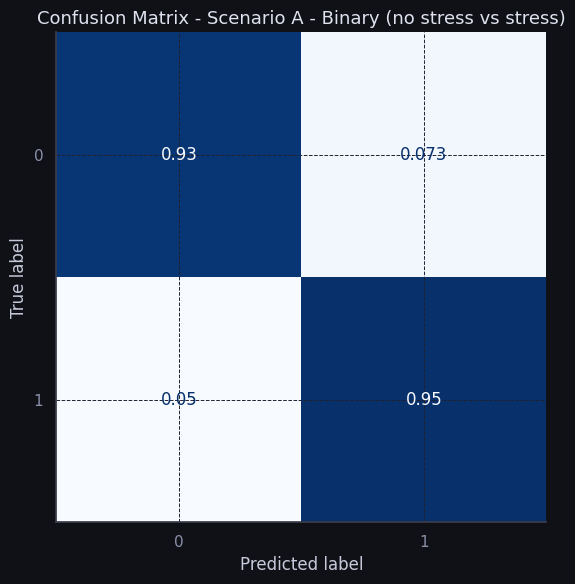

In [28]:
results_A = train_evaluate_svm(
    X, y_A,
    scenario_name='Scenario A - Binary (no stress vs stress)',
    kernel='rbf',
    C=2,
    random_state=20
)


## 3.2 Scenario B – Multi-Class (5 levels)

The model classifies stress into five levels: **no stress** (0), **low** (1), **moderate** (2), **high** (3), **extreme** (4). SVM extends to multi-class via a one-vs-one strategy (default in scikit-learn).


  Scenario B - 5-Class (no stress / low / moderate / high / extreme)
  kernel=rbf  C=10  classes=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  [INFO] SMOTE utilizado.
Cross-val accuracy (5-fold): 0.8765 ± 0.0065

Test-set results:
  Accuracy : 0.8247
  Precision: 0.8265  (weighted)
  Recall   : 0.8247  (weighted)
  F1-Score : 0.8254  (weighted)

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.88      0.87       602
           1       0.72      0.71      0.71       598
           2       0.68      0.71      0.69       601
           3       0.93      0.91      0.92      1199

    accuracy                           0.82      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.83      0.82      0.83      3000



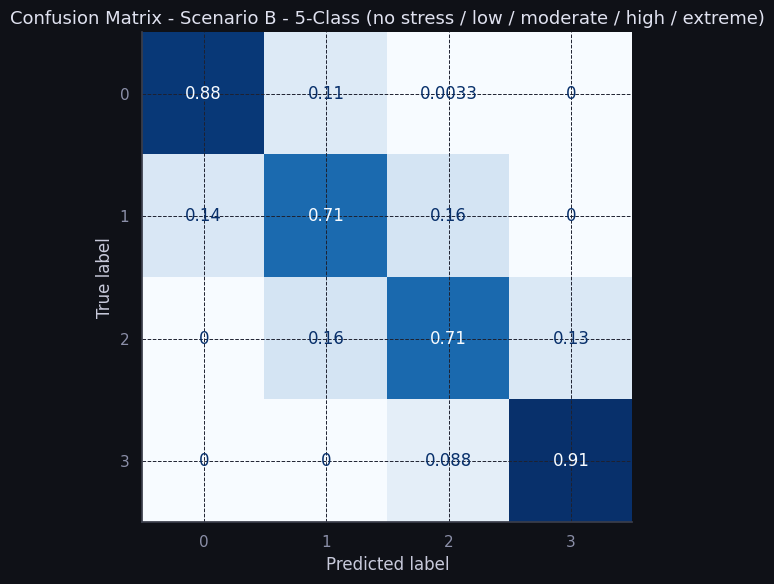

In [18]:
results_B = train_evaluate_svm(
    X, y_B,
    scenario_name='Scenario B - 5-Class (no stress / low / moderate / high / extreme)',
    kernel='rbf',
    C=10
)

## 3.3 Scenario C – Multi-Class (10 levels)

The model classifies stress on a finer 10-level scale (0 = *no stress* … 9 = *maximum*). More classes make the problem harder; the one-vs-one strategy creates C(10,2) = 45 binary classifiers internally.

In [35]:
results_C = train_evaluate_svm(
    X, y_C,
    scenario_name='Scenario C - 10-Class (no stress → maximum)',
    kernel='rbf',## poli , linear 
    C=1
)


  Scenario C - 10-Class (no stress → maximum)
  kernel=rbf  C=1  classes=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  [INFO] SMOTE utilizado.


KeyboardInterrupt: 

## Summary – SVM Performance Across Scenarios

Comparing the three scenarios side-by-side highlights how increasing the number of classes affects performance.

,CV Accuracy (mean),CV Accuracy (std),Test Accuracy,Precision (w),Recall (w),F1-Score (w)
Scenario,,,,,,
A - Binary,0.9560,0.0027,0.9430,0.9437,0.9430,0.9432
B - 5-Class,0.8765,0.0065,0.8247,0.8265,0.8247,0.8254
C - 10-Class,0.5475,0.0054,0.5390,0.5629,0.5390,0.5458


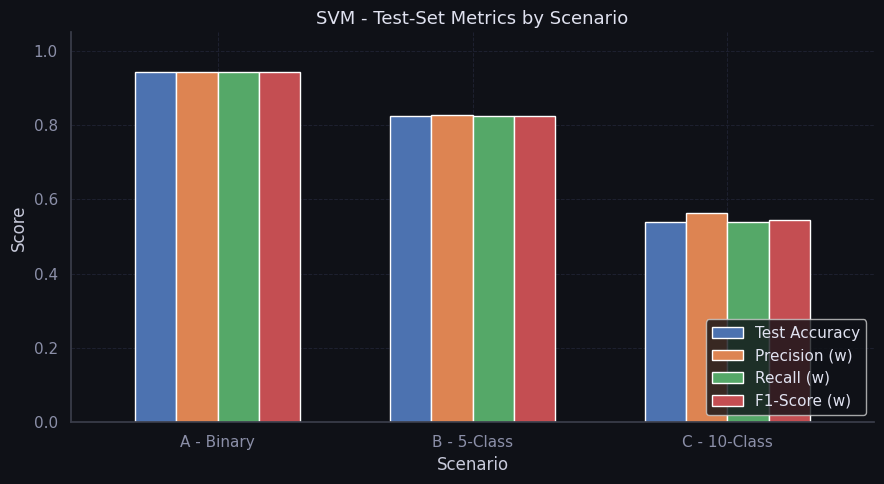

In [34]:
summary = pd.DataFrame({
    'Scenario': ['A - Binary', 'B - 5-Class', 'C - 10-Class'],
    'CV Accuracy (mean)': [results_A['cv_mean'],  results_B['cv_mean'],  results_C['cv_mean']],
    'CV Accuracy (std)':  [results_A['cv_std'],   results_B['cv_std'],   results_C['cv_std']],
    'Test Accuracy':      [results_A['accuracy'], results_B['accuracy'], results_C['accuracy']],
    'Precision (w)':      [results_A['precision'],results_B['precision'],results_C['precision']],
    'Recall (w)':         [results_A['recall'],   results_B['recall'],   results_C['recall']],
    'F1-Score (w)':       [results_A['f1'],       results_B['f1'],       results_C['f1']],
})
summary = summary.set_index('Scenario').round(4)
display(summary)

fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['Test Accuracy', 'Precision (w)', 'Recall (w)', 'F1-Score (w)']
summary[metrics].plot(kind='bar', ax=ax, rot=0, width=0.65)
ax.set_title('SVM - Test-Set Metrics by Scenario', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()